# Análisis — Liga Profesional Argentina 2026 (Sofascore)

**Plataforma de Datos & Scouting** · @datafutbol_ar

Primer análisis sobre la tabla de jugadores. Columnas clave: `player`, `team`, `rating`, `minutesPlayed`.

> ⚠️ **Trampa aprendida:** con `accumulation='per90'`, `minutesPlayed` vale **90 para todos**
> (está normalizado). Los **minutos reales** están en `accumulation='total'`. Por eso traemos
> **las dos tablas**: `total` (minutos + rating) y `per90` (tasas), y las cruzamos.

## Setup

In [1]:
import sys
sys.path.insert(0, r'D:\\PROYECTOS_venv\\02_PROYECTOS\\01_Python\\datafutbol_ar\\plataforma_scouting')   # para ingest.sofascore_loader
sys.path.insert(0, r'D:\\PROYECTOS_venv\\02_PROYECTOS\\01_Python\\datafutbol_ar')   # para scripts.style (identidad de marca)

import pandas as pd
import matplotlib.pyplot as plt
from ingest.sofascore_loader import stats_liga
from scripts.style import set_default_style, COLORS, watermark
set_default_style()
pd.set_option('display.max_columns', None)

LIGA, ANIO = 'Argentina Liga Profesional', '2026'
df_total = stats_liga(ANIO, LIGA, accumulation='total')   # minutos reales + rating
df_p90   = stats_liga(ANIO, LIGA, accumulation='per90')   # tasas por 90'
print('total:', df_total.shape, '| per90:', df_p90.shape)

[API] scrapeando Argentina Liga Profesional 2026 (total)...
Running
[API] guardado stats_argentina_liga_profesional_2026_total.parquet: 821 jugadores x 114 cols
[cache] stats_argentina_liga_profesional_2026_per90.parquet: 821 jugadores x 114 cols
total: (821, 114) | per90: (821, 114)


## 1. La trampa, en vivo: minutos en total vs per90

Mirá la diferencia. En `per90` todos tienen 90; en `total` están los minutos reales.

In [2]:
print('per90  -> minutesPlayed:', df_p90['minutesPlayed'].min(), 'a', df_p90['minutesPlayed'].max())
print('total  -> minutesPlayed:')
print(df_total['minutesPlayed'].describe().round(0))

per90  -> minutesPlayed: 90 a 90
total  -> minutesPlayed:
count     821.0
mean      617.0
std       470.0
min         2.0
25%       184.0
50%       532.0
75%      1000.0
max      1770.0
Name: minutesPlayed, dtype: float64


## 2. Filtrar por minutos (sobre `total`)

Ajustá `MIN_MINUTOS` según las fechas jugadas del torneo (si recién arranca, bajalo).

In [3]:
MIN_MINUTOS = 600   # ajustá: más alto = más exigente
elegibles = df_total[df_total['minutesPlayed'] >= MIN_MINUTOS].copy()
print(f'Jugadores con >= {MIN_MINUTOS} min: {len(elegibles)}')

Jugadores con >= 600 min: 370


## 3. Ranking — mejores ratings del torneo

In [4]:
ranking = (elegibles.sort_values('rating', ascending=False)
                    [['player', 'team', 'minutesPlayed', 'rating']]
                    .head(15).reset_index(drop=True))
ranking

,player,team,minutesPlayed,rating
0,Leandro Paredes,Boca Juniors,1097,7.79
1,Marcelo Agustín Miño,Barracas Central,980,7.61
2,Sebastián Villa,Independiente Rivadavia,1129,7.54
3,Ignacio Arce,Deportivo Riestra,1440,7.51
4,Juan Fernando Quintero,River Plate,638,7.46
5,Leandro Lozano,Argentinos Juniors,1274,7.44
6,Ángel Di María,Rosario Central,1047,7.44
7,Aaron Molinas,Defensa y Justicia,1348,7.43
8,Franco Ibarra,Rosario Central,1492,7.42
9,Tiago Palacios,Estudiantes de La Plata,737,7.32


## 4. Visualización con identidad de marca — Top 12 por rating

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

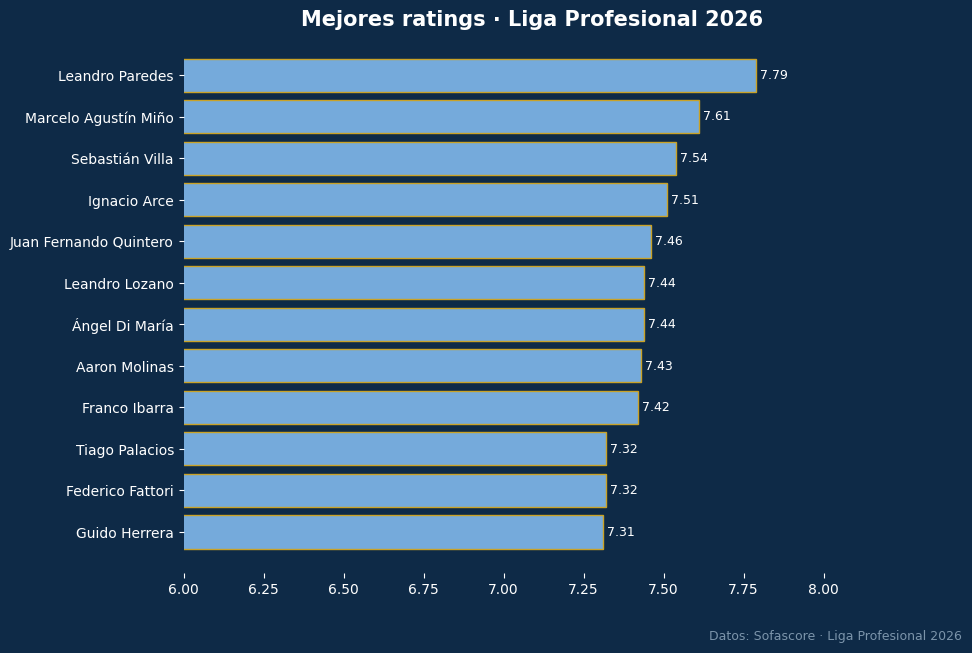

In [5]:
top = elegibles.sort_values('rating', ascending=False).head(12).iloc[::-1]  # mayor arriba

fig, ax = plt.subplots(figsize=(9, 7), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
ax.barh(top['player'], top['rating'], color=COLORS['primary'], edgecolor=COLORS['accent'])
ax.set_xlim(left=6.0)   # ratings ~6-8: recortamos para ver diferencias
ax.set_title('Mejores ratings · Liga Profesional 2026',
             color=COLORS['text'], fontsize=15, weight='bold')
ax.tick_params(colors=COLORS['text'])
for s in ax.spines.values():
    s.set_visible(False)
for i, v in enumerate(top['rating']):
    ax.text(v, i, f' {v:.2f}', va='center', color=COLORS['text'], fontsize=9)
watermark(fig, 'Datos: Sofascore · Liga Profesional 2026')
fig.savefig('../outputs/ligapro_2026_top_ratings.png', dpi=200,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 5. Rankings por-90 (cruzando minutos reales)

Pegamos los minutos reales (de `total`) a la tabla `per90` y filtramos igual. Así las
tasas por-90 son justas y solo miramos jugadores con minutos suficientes.

In [6]:
minutos = df_total[['player', 'team', 'minutesPlayed']].rename(columns={'minutesPlayed': 'minutos'})
p90 = df_p90.merge(minutos, on=['player', 'team'], how='left')
p90f = p90[p90['minutos'] >= MIN_MINUTOS]
print('jugadores en per90 filtrado:', len(p90f))

for col in ['expectedGoals', 'expectedAssists', 'interceptions', 'keyPasses']:
    if col in p90f.columns:
        print(f'\n— Top 5 {col} por 90 (min>={MIN_MINUTOS}) —')
        print(p90f.sort_values(col, ascending=False)[['player','team',col]].head().to_string(index=False))

jugadores en per90 filtrado: 370

— Top 5 expectedGoals por 90 (min>=600) —
                    player                   team  expectedGoals
              Óscar Romero                Huracán           0.24
              Enzo Copetti        Rosario Central           0.20
        Facundo Jainikoski     Argentinos Juniors           0.16
Francisco González Metilli Club Atlético Belgrano           0.14
          Ramiro Hernandes Club Atlético Belgrano           0.14

— Top 5 expectedAssists por 90 (min>=600) —
                    player                   team  expectedAssists
    Juan Fernando Quintero            River Plate             0.13
          Agustín Auzmendi     Gimnasia y Esgrima             0.12
Francisco González Metilli Club Atlético Belgrano             0.11
              Diego Valdés        Vélez Sarsfield             0.09
            Ángel Di María        Rosario Central             0.09

— Top 5 interceptions por 90 (min>=600) —
          player            team  intercepti

## 6. Mapear columnas clave a español (legibilidad / captions)

In [8]:
MAPA = {
    'player': 'jugador', 'team': 'equipo', 'minutesPlayed': 'minutos',
    'appearances': 'partidos', 'rating': 'rating_sofascore',
    'goals': 'goles', 'assists': 'asistencias',
    'expectedGoals': 'xG', 'expectedAssists': 'xA',
    'bigChancesCreated': 'ocasiones_creadas', 'keyPasses': 'pases_clave',
    'accuratePassesPercentage': 'precision_pases_%',
    'interceptions': 'intercepciones', 'tackles': 'entradas',
    'totalDuelsWonPercentage': 'duelos_ganados_%',
    'saves': 'atajadas', 'yellowCards': 'amarillas', 'redCards': 'rojas',
}
df_es = elegibles.rename(columns={k: v for k, v in MAPA.items() if k in elegibles.columns})
cols_es = [v for v in MAPA.values() if v in df_es.columns]
df_es.sort_values('rating_sofascore', ascending=False)[cols_es].head(10)

,jugador,equipo,minutos,partidos,rating_sofascore,goles,asistencias,xG,xA,ocasiones_creadas,pases_clave,precision_pases_%,intercepciones,entradas,duelos_ganados_%,atajadas,amarillas,rojas
1,Leandro Paredes,Boca Juniors,1097,15,7.79,2,3,0.11,0.29,8,29,89.03,10,22,65.96,0,7,0
3,Marcelo Agustín Miño,Barracas Central,980,11,7.61,0,0,NaN,NaN,0,0,50.35,0,0,77.78,50,1,0
4,Sebastián Villa,Independiente Rivadavia,1129,14,7.54,0,5,NaN,0.43,10,49,76.67,4,11,56.36,0,2,0
5,Ignacio Arce,Deportivo Riestra,1440,16,7.51,0,0,NaN,NaN,1,3,47.32,1,1,88.24,55,4,0
7,Juan Fernando Quintero,River Plate,638,14,7.46,3,3,0.24,0.95,7,28,84.88,3,2,44.83,0,0,0
8,Leandro Lozano,Argentinos Juniors,1274,14,7.44,0,2,0.05,0.76,4,24,81.29,16,29,66.89,0,3,0
9,Ángel Di María,Rosario Central,1047,14,7.44,5,4,0.28,1.03,8,35,74.43,7,7,42.62,0,2,0
10,Aaron Molinas,Defensa y Justicia,1348,15,7.43,3,4,NaN,0.09,4,32,86.21,11,20,52.17,0,3,0
11,Franco Ibarra,Rosario Central,1492,17,7.42,0,1,0.04,0.16,2,19,86.30,31,80,69.58,0,7,0
14,Tiago Palacios,Estudiantes de La Plata,737,13,7.32,3,1,NaN,NaN,4,16,81.64,4,10,45.92,0,2,0


## Próximo paso — scouting sub-23

Para el contenido del receso (scouting de pibes), sumamos `scrape_player_details()` para
traer **fecha de nacimiento** y **posición**, lo cruzamos por jugador, calculamos la edad
y filtramos `edad <= 23`. Con eso: *Top sub-23 por rating* o *por xG+xA/90*. ¿Lo encaramos?